In [ ]:
# Import Libraries
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from PIL import Image
from sklearn.model_selection import train_test_split
import random


In [ ]:
# Define Dataset Paths and Load Ground Truth

dataset_path = r"C:\Users\user\Desktop\MASTER\NN\HW3\FullIJCNN2013\FullIJCNN2013"
images_path = dataset_path
ground_truth_file = os.path.join(dataset_path, 'gt.txt')


columns = ['Filename', 'X1', 'Y1', 'X2', 'Y2', 'ClassID']
gt_df = pd.read_csv(ground_truth_file, sep=';', names=columns)


In [ ]:


print(f"Total number of images in the dataset: {len(os.listdir(images_path))}")
print(f"Total number of annotations in the ground truth: {len(gt_df)}")
print(f"Number of unique traffic sign classes: {gt_df['ClassID'].nunique()}")


Total number of images in the dataset: 945
Total number of annotations in the ground truth: 1213
Number of unique traffic sign classes: 43


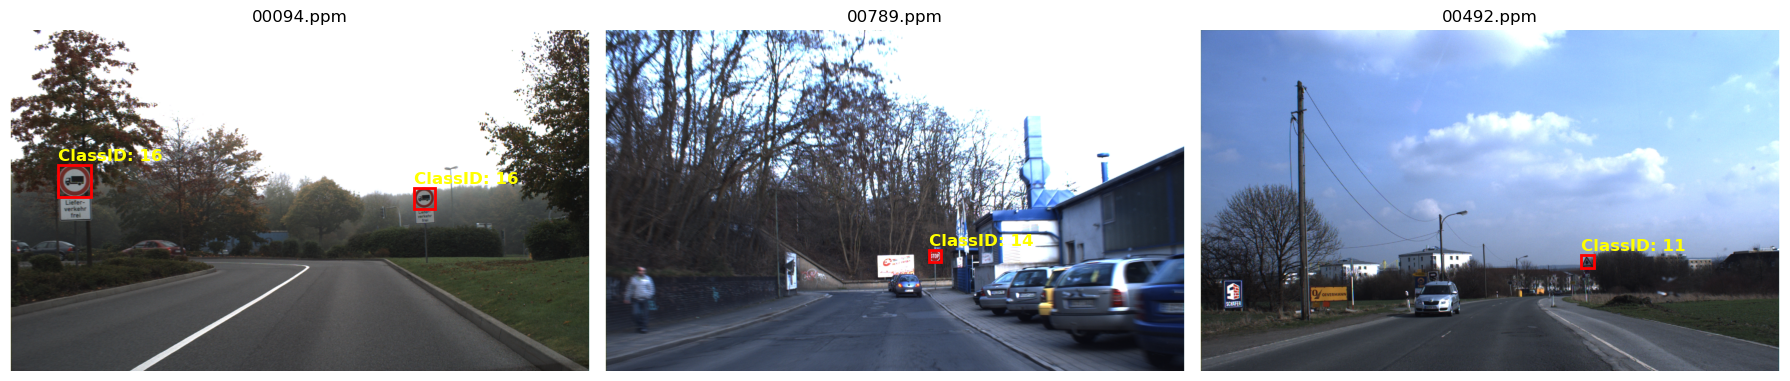

In [ ]:
# Display 3 Images with Annotations

image_filenames = gt_df['Filename'].unique()
selected_images = random.sample(list(image_filenames), 3)

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

for ax, img_name in zip(axes, selected_images):
    img_path = os.path.join(images_path, img_name)
    img = Image.open(img_path)
    ax.imshow(img)
    ax.axis('off')
    ax.set_title(img_name)
    annotations = gt_df[gt_df['Filename'] == img_name]
    # Draw bounding boxes and class labels
    for idx, row in annotations.iterrows():
        x1, y1, x2, y2 = row['X1'], row['Y1'], row['X2'], row['Y2']
        width, height = x2 - x1, y2 - y1
        rect = patches.Rectangle((x1, y1), width, height, linewidth=2, edgecolor='red', facecolor='none')
        ax.add_patch(rect)
        # Add class label
        ax.text(x1, y1 - 10, f"ClassID: {row['ClassID']}", color='yellow', fontsize=12, weight='bold')

plt.tight_layout()
plt.show()


In [ ]:
# Categorize Objects into Small, Medium, and Large

def categorize_size(width):
    if width < 32:
        return 'Small'
    elif 32 <= width <= 45:
        return 'Medium'
    else:
        return 'Large'
gt_df['Width'] = gt_df['X2'] - gt_df['X1']
gt_df['SizeCategory'] = gt_df['Width'].apply(categorize_size)


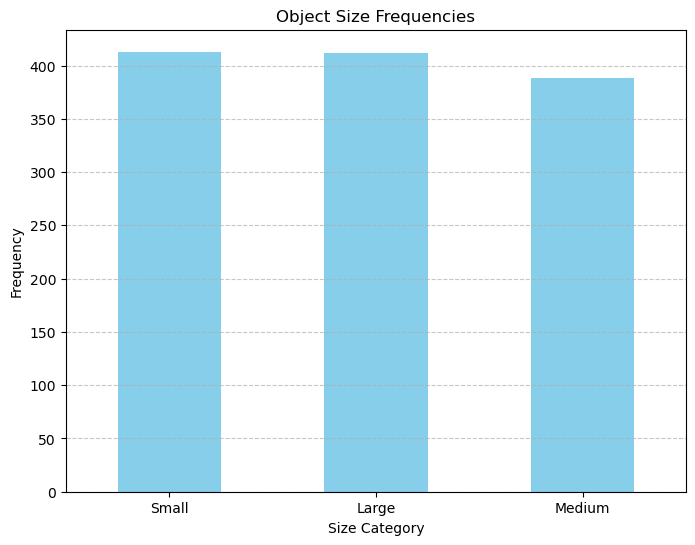

In [ ]:
# Plot Histogram of Object Size Frequencies

size_counts = gt_df['SizeCategory'].value_counts()

plt.figure(figsize=(8, 6))
size_counts.plot(kind='bar', color='skyblue')
plt.title('Object Size Frequencies')
plt.xlabel('Size Category')
plt.ylabel('Frequency')
plt.xticks(rotation=0)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()


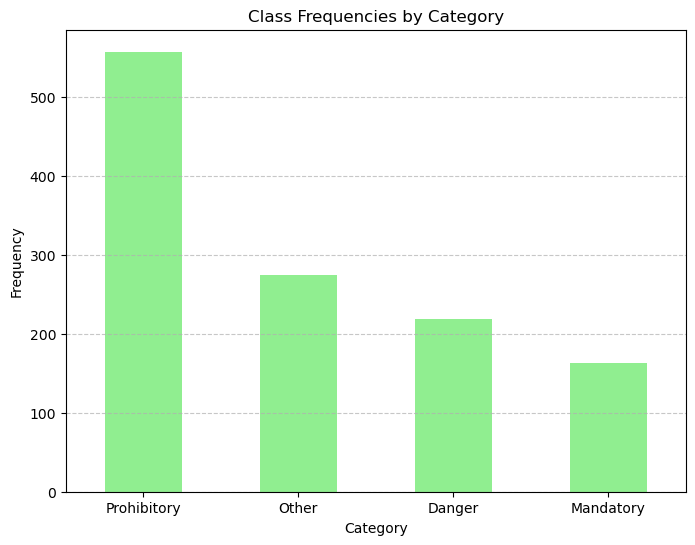

In [ ]:
# Plot Histogram of Class Frequencies (4 Categories)

# Define class categories mapping
prohibitory = [0, 1, 2, 3, 4, 5, 7, 8, 9, 10, 15, 16]
danger = [11, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31]
mandatory = [33, 34, 35, 36, 37, 38, 39, 40]
other = [6, 12, 13, 14, 17, 32, 41, 42]

def map_category(class_id):
    if class_id in prohibitory:
        return 'Prohibitory'
    elif class_id in danger:
        return 'Danger'
    elif class_id in mandatory:
        return 'Mandatory'
    else:
        return 'Other'
gt_df['Category'] = gt_df['ClassID'].apply(map_category)
category_counts = gt_df['Category'].value_counts()

plt.figure(figsize=(8, 6))
category_counts.plot(kind='bar', color='lightgreen')
plt.title('Class Frequencies by Category')
plt.xlabel('Category')
plt.ylabel('Frequency')
plt.xticks(rotation=0)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()


In [ ]:
# Split Dataset into Training and Evaluation Sets
unique_images = gt_df['Filename'].unique()
image_categories = gt_df.groupby('Filename')['Category'].agg(lambda x: x.mode()[0]).reset_index()
train_images, eval_images = train_test_split(
    image_categories['Filename'],
    test_size=0.2,
    stratify=image_categories['Category'],
    random_state=42
)

# Create training and evaluation annotations
train_df = gt_df[gt_df['Filename'].isin(train_images)].reset_index(drop=True)
eval_df = gt_df[gt_df['Filename'].isin(eval_images)].reset_index(drop=True)


In [ ]:
# Store Split Information

# Save the list 
train_images.to_frame().to_csv('train_images.txt', index=False, header=False)
eval_images.to_frame().to_csv('eval_images.txt', index=False, header=False)

# Save the annotations 
train_df.to_csv('train_annotations.csv', index=False)
eval_df.to_csv('eval_annotations.csv', index=False)


Training and evaluation sets have been saved.


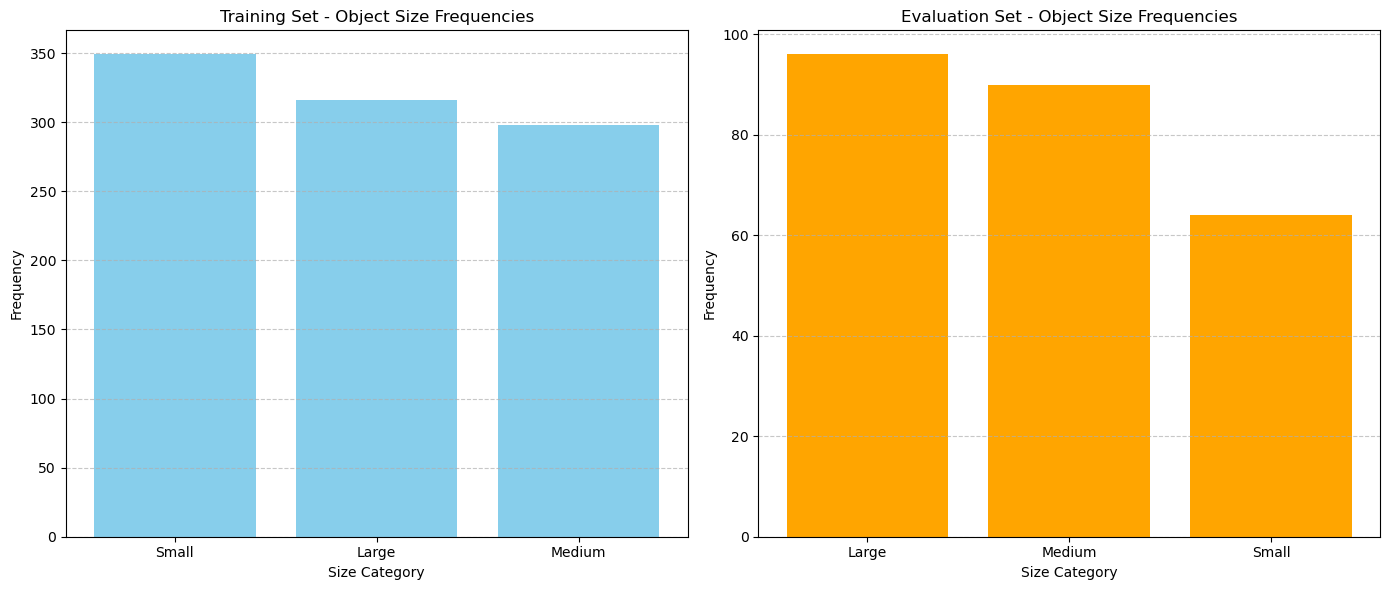

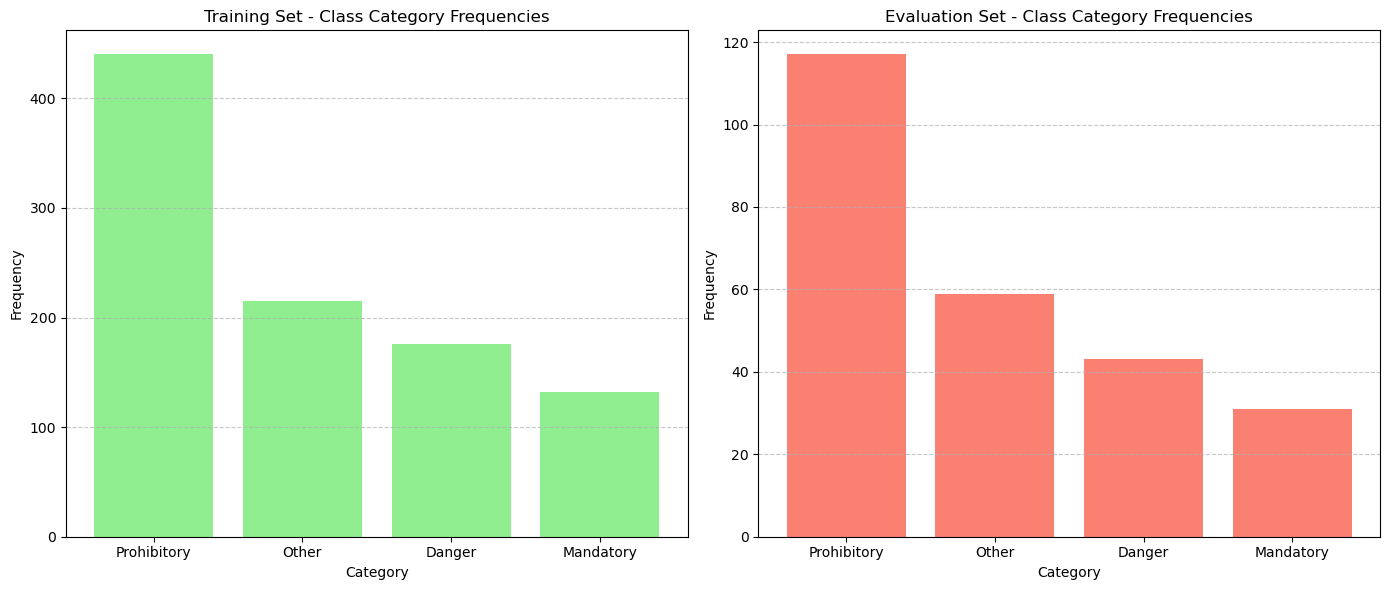

In [ ]:
# Plot Histograms for Training and Evaluation Sets

train_size_counts = train_df['SizeCategory'].value_counts()
eval_size_counts = eval_df['SizeCategory'].value_counts()

train_category_counts = train_df['Category'].value_counts()
eval_category_counts = eval_df['Category'].value_counts()

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Training set size distributiom
axes[0].bar(train_size_counts.index, train_size_counts.values, color='skyblue')
axes[0].set_title('Training Set - Object Size Frequencies')
axes[0].set_xlabel('Size Category')
axes[0].set_ylabel('Frequency')
axes[0].grid(axis='y', linestyle='--', alpha=0.7)

# Evaluation set size distribution
axes[1].bar(eval_size_counts.index, eval_size_counts.values, color='orange')
axes[1].set_title('Evaluation Set - Object Size Frequencies')
axes[1].set_xlabel('Size Category')
axes[1].set_ylabel('Frequency')
axes[1].grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

# Plot class category
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Training set class 
axes[0].bar(train_category_counts.index, train_category_counts.values, color='lightgreen')
axes[0].set_title('Training Set - Class Category Frequencies')
axes[0].set_xlabel('Category')
axes[0].set_ylabel('Frequency')
axes[0].grid(axis='y', linestyle='--', alpha=0.7)

# Evaluation set class 
axes[1].bar(eval_category_counts.index, eval_category_counts.values, color='salmon')
axes[1].set_title('Evaluation Set - Class Category Frequencies')
axes[1].set_xlabel('Category')
axes[1].set_ylabel('Frequency')
axes[1].grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()


In [ ]:
# Import Necessary Libraries

import torch
import torchvision
from torchvision.models.detection.faster_rcnn import FastRCNNPredictor
from torchvision import transforms
from torch.utils.data import Dataset, DataLoader
from PIL import Image
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import time
from collections import defaultdict
from tqdm import tqdm
import random
import numpy as np


In [ ]:
# Define IoU Calculation Function

def calculate_iou(boxA, boxB):
    # Compute the intersection
    xA = max(boxA[0], boxB[0])
    yA = max(boxA[1], boxB[1])
    xB = min(boxA[2], boxB[2])
    yB = min(boxA[3], boxB[3])
    
    interWidth = max(0, xB - xA)
    interHeight = max(0, yB - yA)
    interArea = interWidth * interHeight
    
    # Compute the area of both boxes
    boxAArea = (boxA[2] - boxA[0]) * (boxA[3] - boxA[1])
    boxBArea = (boxB[2] - boxB[0]) * (boxB[3] - boxB[1])
    
    # Compute the IoU
    iou = interArea / float(boxAArea + boxBArea - interArea + 1e-6)
    return iou


In [ ]:
# Define Custom Dataset Class with Category Mapping

class TrafficSignDataset(Dataset):
    def __init__(self, dataframe, image_dir, transforms=None):
        self.dataframe = dataframe
        self.image_dir = image_dir
        self.transforms = transforms
        self.image_filenames = dataframe['Filename'].unique()
        self.image_filename_to_idx = {filename: idx for idx, filename in enumerate(self.image_filenames)}
        
        self.image_annotations = dataframe.groupby('Filename')
        
    def __len__(self):
        return len(self.image_filenames)
    
    def __getitem__(self, idx):
        img_filename = self.image_filenames[idx]
        img_path = os.path.join(self.image_dir, img_filename)
        img = Image.open(img_path).convert("RGB")
        annots = self.image_annotations.get_group(img_filename)
        boxes = annots[['X1', 'Y1', 'X2', 'Y2']].values
        labels = annots['Category'].values
        label_mapping = {'Prohibitory': 1, 'Danger': 2, 'Mandatory': 3, 'Other': 4}
        labels = np.array([label_mapping[label] for label in labels])
        boxes = torch.as_tensor(boxes, dtype=torch.float32)
        labels = torch.as_tensor(labels, dtype=torch.int64)
        
        target = {}
        target['boxes'] = boxes
        target['labels'] = labels
        target['image_id'] = torch.tensor([idx])
        area = (boxes[:, 3] - boxes[:, 1]) * (boxes[:, 2] - boxes[:, 0])
        target['area'] = area
        target['iscrowd'] = torch.zeros((boxes.shape[0],), dtype=torch.int64)
        
        if self.transforms:
            img = self.transforms(img)
        
        return img, target


In [ ]:
# Data Transformations
def get_transform(train):
    transforms_list = []
    transforms_list.append(transforms.ToTensor())
    return transforms.Compose(transforms_list)


In [ ]:
# Create Datasets and DataLoaders
train_dataset = TrafficSignDataset(train_df, images_path, transforms=get_transform(train=True))
eval_dataset = TrafficSignDataset(eval_df, images_path, transforms=get_transform(train=False))
train_loader = DataLoader(train_dataset, batch_size=4, shuffle=True, collate_fn=lambda x: tuple(zip(*x)))
eval_loader = DataLoader(eval_dataset, batch_size=2, shuffle=False, collate_fn=lambda x: tuple(zip(*x)))


In [ ]:
#  Load Pre-trained Model and Modify for Fine-Tuning
model = torchvision.models.detection.fasterrcnn_resnet50_fpn(pretrained=True, 
                                                            pretrained_backbone=True, 
                                                            trainable_backbone_layers=0, 
                                                            progress=True)

num_classes = 4 + 1  # Prohibitory, Danger, Mandatory, Other, Background
in_features = model.roi_heads.box_predictor.cls_score.in_features
model.roi_heads.box_predictor = FastRCNNPredictor(in_features, num_classes)

# Move model to GPU 
device = torch.device('cuda') if torch.cuda.is_available() else torch.device('cpu')
model.to(device)


C:\Users\user\AppData\Roaming\Python\Python312\site-packages\torchvision\models\_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
C:\Users\user\AppData\Roaming\Python\Python312\site-packages\torchvision\models\_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=FasterRCNN_ResNet50_FPN_Weights.COCO_V1`. You can also use `weights=FasterRCNN_ResNet50_FPN_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)
C:\Users\user\AppData\Roaming\Python\Python312\site-packages\torchvision\models\_utils.py:208: UserWarning: The parameter 'pretrained_backbone' is deprecated since 0.13 and may be removed in the future, please use 'weights_backbone' instead.
  warnings.warn(
C:\Users\user\AppData\Roaming\Python\Python312\site-

FasterRCNN(
  (transform): GeneralizedRCNNTransform(
      Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
      Resize(min_size=(800,), max_size=1333, mode='bilinear')
  )
  (backbone): BackboneWithFPN(
    (body): IntermediateLayerGetter(
      (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
      (bn1): FrozenBatchNorm2d(64, eps=0.0)
      (relu): ReLU(inplace=True)
      (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
      (layer1): Sequential(
        (0): Bottleneck(
          (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
          (bn1): FrozenBatchNorm2d(64, eps=0.0)
          (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
          (bn2): FrozenBatchNorm2d(64, eps=0.0)
          (conv3): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
          (bn3): FrozenBatchNorm2d(256, eps=0.0)
          (relu): ReLU(

In [17]:
device

device(type='cuda')

In [ ]:
# Define Optimizer and Learning Rate Scheduler
params = [p for p in model.parameters() if p.requires_grad]
optimizer = torch.optim.SGD(params, lr=0.005, momentum=0.9, weight_decay=0.0005)
lr_scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=3, gamma=0.1)


In [ ]:
# Training Loop
num_epochs = 5

for epoch in range(num_epochs):
    model.train()
    epoch_loss = 0
    for images, targets in tqdm(train_loader, desc=f"Epoch {epoch+1}/{num_epochs}"):
        images = list(image.to(device) for image in images)
        targets = [{k: v.to(device) for k, v in t.items()} for t in targets]
        
        optimizer.zero_grad()
        
        # Forward pass
        loss_dict = model(images, targets)
        losses = sum(loss for loss in loss_dict.values())
        
        # Backward pass
        losses.backward()
        optimizer.step()
        
        epoch_loss += losses.item()
    
    # Update the learning rate
    lr_scheduler.step()
    
    avg_loss = epoch_loss / len(train_loader)
    print(f"Epoch {epoch+1}, Loss: {avg_loss:.4f}")


Epoch 1/5: 100%|██████████| 148/148 [16:33<00:00,  6.71s/it]


Epoch 1, Loss: 0.2243


Epoch 2/5: 100%|██████████| 148/148 [16:16<00:00,  6.60s/it]


Epoch 2, Loss: 0.1093


Epoch 3/5: 100%|██████████| 148/148 [16:16<00:00,  6.60s/it]


Epoch 3, Loss: 0.0823


Epoch 4/5: 100%|██████████| 148/148 [16:23<00:00,  6.65s/it]


Epoch 4, Loss: 0.0632


Epoch 5/5: 100%|██████████| 148/148 [16:14<00:00,  6.59s/it]

Epoch 5, Loss: 0.0605


In [112]:
!pip install pycocotools
!pip install torchmetrics


Defaulting to user installation because normal site-packages is not writeable
Defaulting to user installation because normal site-packages is not writeable


In [ ]:
# Save the Trained Model

import torch
model_save_path = r'C:\Users\user\Desktop\MASTER\NN\HW3\fasterrcnn_resnet50_fpn_traffic_signs.pth'
torch.save(model.state_dict(), model_save_path)

print(f"Model saved successfully at {model_save_path}")


Model saved successfully at C:\Users\user\Desktop\MASTER\NN\HW3\fasterrcnn_resnet50_fpn_traffic_signs.pth


In [ ]:
# CInstall and Import torchmetrics
!pip install torchmetrics

import torch
from torchmetrics.detection.mean_ap import MeanAveragePrecision
from tqdm import tqdm


Defaulting to user installation because normal site-packages is not writeable


In [ ]:
# Initialize the mAP 
num_classes = 4  # Prohibitory, Danger, Mandatory, Other
metric = MeanAveragePrecision(class_metrics=True)
metric.to(device)


MeanAveragePrecision()

In [ ]:
# Implement Accurate mAP Calculation Using torchmetrics

category_names = {1: 'Prohibitory', 2: 'Danger', 3: 'Mandatory', 4: 'Other'}

for images, targets in tqdm(eval_loader, desc="Evaluating mAP"):
    images = list(img.to(device) for img in images)
    targets = [{k: v.to(device) for k, v in t.items()} for t in targets]
    model.eval()
    with torch.no_grad():
        predictions = model(images)
    metric.update(predictions, targets)

final_mAP = metric.compute()
overall_map = final_mAP['map'].item()
overall_map_50 = final_mAP['map_50'].item()
overall_map_75 = final_mAP['map_75'].item()

print(f"Final mAP: {overall_map:.4f}")
print(f"mAP@0.50: {overall_map_50:.4f}")
print(f"mAP@0.75: {overall_map_75:.4f}")
print("\nPer-Category mAP:")


Evaluating mAP: 100%|██████████| 75/75 [00:22<00:00,  3.29it/s]


Final mAP: 0.7826
mAP@0.50: 0.9517
mAP@0.75: 0.9382

Per-Category mAP:
Prohibitory mAP: 0.8409
Danger mAP: 0.8052
Mandatory mAP: 0.7954
Other mAP: 0.6888


Evaluating AP at different IoUs: 100%|██████████| 10/10 [03:44<00:00, 22.49s/it]


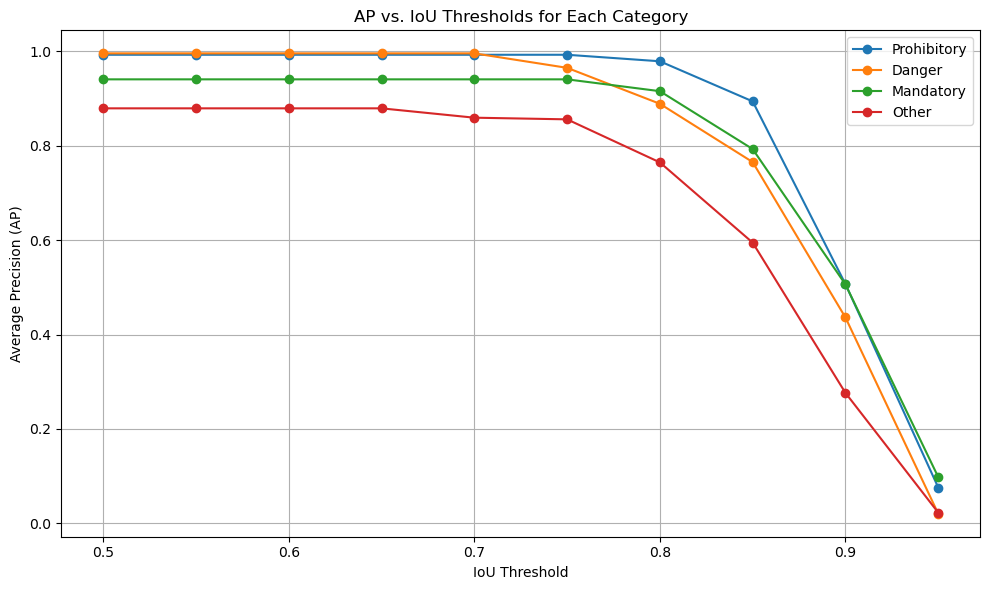

In [ ]:
# Plot AP vs. IoU for the 4 Classes

import matplotlib.pyplot as plt
from collections import defaultdict
from tqdm import tqdm
import numpy as np

iou_thresholds = np.arange(0.5, 0.96, 0.05)

category_ap_iou = defaultdict(list)
for iou in tqdm(iou_thresholds, desc="Evaluating AP at different IoUs"):
    current_metric = MeanAveragePrecision(class_metrics=True, iou_thresholds=[iou])
    current_metric.to(device)
    for images, targets in eval_loader:
        images = list(img.to(device) for img in images)
        targets = [{k: v.to(device) for k, v in t.items()} for t in targets]
        
        model.eval()
        with torch.no_grad():
            predictions = model(images)
        current_metric.update(predictions, targets)
    current_mAP = current_metric.compute()
    for idx, category in category_names.items():
        try:
            mAP = current_mAP['map_per_class'][idx-1].item()
            category_ap_iou[category].append(mAP)
        except (KeyError, IndexError):
            category_ap_iou[category].append(0.0)

plt.figure(figsize=(10, 6))
for category in category_names.values():
    plt.plot(iou_thresholds, category_ap_iou[category], marker='o', label=category)

plt.title('AP vs. IoU Thresholds for Each Category')
plt.xlabel('IoU Threshold')
plt.ylabel('Average Precision (AP)')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


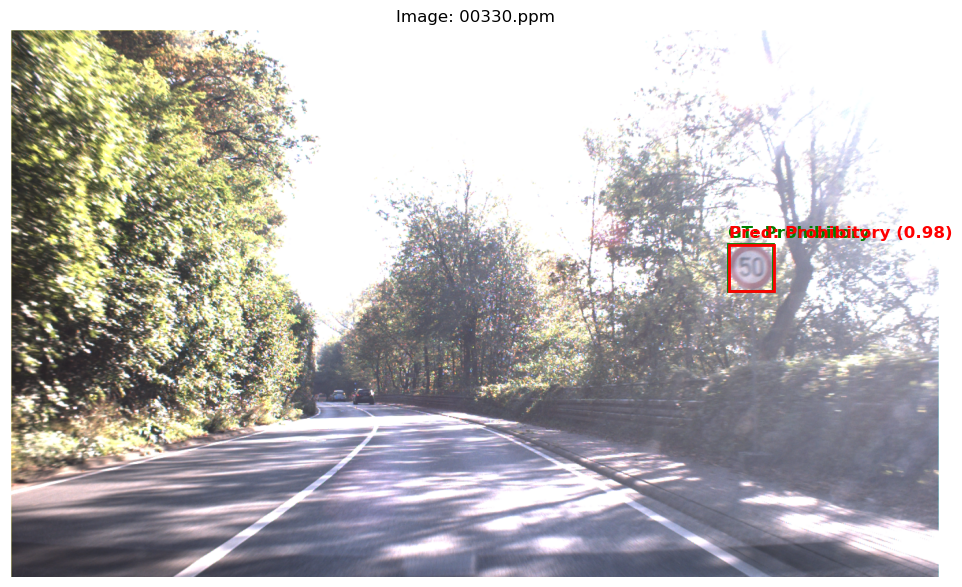

In [ ]:
# Display Example Result from Evaluation Dataset

import matplotlib.patches as patches
import random
import numpy as np

category_names = {1: 'Prohibitory', 2: 'Danger', 3: 'Mandatory', 4: 'Other'}

random_idx = random.randint(0, len(eval_dataset) - 1)
img, target = eval_dataset[random_idx]
img_filename = eval_dataset.image_filenames[random_idx]

model.eval()
with torch.no_grad():
    img_input = img.to(device)
    prediction = model([img_input])[0]
img_cpu = img.cpu().permute(1, 2, 0).numpy()
img_cpu = np.clip(img_cpu, 0, 1)
fig, ax = plt.subplots(1, figsize=(12, 8))
ax.imshow(img_cpu)
for idx in range(len(target['boxes'])):
    box = target['boxes'][idx].cpu().numpy()
    label = target['labels'][idx].item()
    rect = patches.Rectangle((box[0], box[1]), box[2]-box[0], box[3]-box[1],
                             linewidth=2, edgecolor='green', facecolor='none')
    ax.add_patch(rect)
    ax.text(box[0], box[1]-10, f"GT: {category_names.get(label, label)}", 
            color='green', fontsize=12, weight='bold')
pred_boxes = prediction['boxes'].cpu().numpy()
pred_scores = prediction['scores'].cpu().numpy()
pred_labels = prediction['labels'].cpu().numpy()
score_threshold = 0.5
for idx in range(len(pred_boxes)):
    if pred_scores[idx] >= score_threshold:
        box = pred_boxes[idx]
        label = pred_labels[idx]
        score = pred_scores[idx]
        rect = patches.Rectangle((box[0], box[1]), box[2]-box[0], box[3]-box[1],
                                 linewidth=2, edgecolor='red', facecolor='none')
        ax.add_patch(rect)
        ax.text(box[0], box[1]-10, f"Pred: {category_names.get(label, label)} ({score:.2f})", 
                color='red', fontsize=12, weight='bold')

ax.axis('off')
plt.title(f"Image: {img_filename}")
plt.show()


In [ ]:
# Categorize Objects into Small, Medium, and Large

def categorize_size(width):
    if width < 32:
        return 'Small'
    elif 32 <= width <= 45:
        return 'Medium'
    else:
        return 'Large'

gt_df['Width'] = gt_df['X2'] - gt_df['X1']
gt_df['SizeCategory'] = gt_df['Width'].apply(categorize_size)


In [ ]:


def categorize_pred_size(box):
    width = box[2] - box[0]  
    if width < 32:
        return 'Small'
    elif 32 <= width <= 45:
        return 'Medium'
    else:
        return 'Large'


In [ ]:
# Initialize mAP Metrics for Size Categories

from torchmetrics.detection.mean_ap import MeanAveragePrecision

map_small = MeanAveragePrecision(class_metrics=True)
map_medium = MeanAveragePrecision(class_metrics=True)
map_large = MeanAveragePrecision(class_metrics=True)

map_small.to(device)
map_medium.to(device)
map_large.to(device)


MeanAveragePrecision()

In [ ]:
# Evaluate mAP for Each Size Category

from tqdm import tqdm
category_names = {1: 'Prohibitory', 2: 'Danger', 3: 'Mandatory', 4: 'Other'}

for images, targets in tqdm(eval_loader, desc="Evaluating mAP for Size Categories"):
    images = list(img.to(device) for img in images)
    targets = [{k: v.to(device) for k, v in t.items()} for t in targets]
    model.eval()
    with torch.no_grad():
        predictions = model(images)
    for img_idx in range(len(images)):
        gt_boxes = targets[img_idx]['boxes']
        gt_labels = targets[img_idx]['labels']
        pred_boxes = predictions[img_idx]['boxes']
        pred_labels = predictions[img_idx]['labels']
        pred_scores = predictions[img_idx]['scores']
        gt_size_categories = [categorize_size(box[2] - box[0]).encode('utf-8') for box in gt_boxes]
        pred_size_categories = [categorize_pred_size(box).encode('utf-8') for box in pred_boxes]
        
        for size_category, metric in zip(['Small', 'Medium', 'Large'], [map_small, map_medium, map_large]):
            filtered_gt = {
                'boxes': gt_boxes[[i for i, sc in enumerate(gt_size_categories) if sc.decode() == size_category]],
                'labels': gt_labels[[i for i, sc in enumerate(gt_size_categories) if sc.decode() == size_category]]
            }
            
            filtered_preds = {
                'boxes': pred_boxes[[i for i, sc in enumerate(pred_size_categories) if sc.decode() == size_category]],
                'labels': pred_labels[[i for i, sc in enumerate(pred_size_categories) if sc.decode() == size_category]],
                'scores': pred_scores[[i for i, sc in enumerate(pred_size_categories) if sc.decode() == size_category]]
            }
            
            if len(filtered_gt['boxes']) > 0 or len(filtered_preds['boxes']) > 0:
                metric.update([filtered_preds], [filtered_gt])


Evaluating mAP for Size Categories: 100%|██████████| 75/75 [00:23<00:00,  3.25it/s]


In [ ]:
# Compute and Display Final mAP Results
final_mAP_small = map_small.compute()
final_mAP_medium = map_medium.compute()
final_mAP_large = map_large.compute()

overall_map_small = final_mAP_small['map'].item()
overall_map_small_50 = final_mAP_small['map_50'].item()
overall_map_small_75 = final_mAP_small['map_75'].item()

overall_map_medium = final_mAP_medium['map'].item()
overall_map_medium_50 = final_mAP_medium['map_50'].item()
overall_map_medium_75 = final_mAP_medium['map_75'].item()

overall_map_large = final_mAP_large['map'].item()
overall_map_large_50 = final_mAP_large['map_50'].item()
overall_map_large_75 = final_mAP_large['map_75'].item()

print("Final mAP for Each Size Category:\n")

print("Small Objects:")
print(f"  mAP: {overall_map_small:.4f}")
print(f"  mAP@0.50: {overall_map_small_50:.4f}")
print(f"  mAP@0.75: {overall_map_small_75:.4f}\n")

print("Medium Objects:")
print(f"  mAP: {overall_map_medium:.4f}")
print(f"  mAP@0.50: {overall_map_medium_50:.4f}")
print(f"  mAP@0.75: {overall_map_medium_75:.4f}\n")

print("Large Objects:")
print(f"  mAP: {overall_map_large:.4f}")
print(f"  mAP@0.50: {overall_map_large_50:.4f}")
print(f"  mAP@0.75: {overall_map_large_75:.4f}\n")


Final mAP for Each Size Category:

Small Objects:
  mAP: 0.5547
  mAP@0.50: 0.7487
  mAP@0.75: 0.7470

Medium Objects:
  mAP: 0.6603
  mAP@0.50: 0.7828
  mAP@0.75: 0.7630

Large Objects:
  mAP: 0.8119
  mAP@0.50: 0.9416
  mAP@0.75: 0.9297



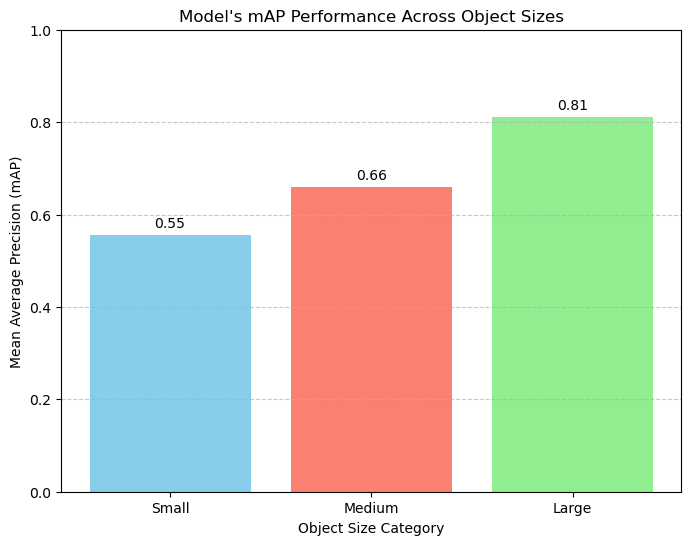

In [ ]:
# Plot AP vs. IoU for Each Size Category

import matplotlib.pyplot as plt
from collections import defaultdict
import numpy as np
iou_thresholds = np.arange(0.5, 0.96, 0.05)
size_categories = ['Small', 'Medium', 'Large']
mAP_values = {
    'Small': [],
    'Medium': [],
    'Large': []
}

plt.figure(figsize=(8, 6))
bars = plt.bar(size_categories, 
              [overall_map_small, overall_map_medium, overall_map_large],
              color=['skyblue', 'salmon', 'lightgreen'])
for bar, mAP in zip(bars, [overall_map_small, overall_map_medium, overall_map_large]):
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2.0, yval + 0.01, f"{mAP:.2f}", ha='center', va='bottom')

plt.title("Model's mAP Performance Across Object Sizes")
plt.xlabel("Object Size Category")
plt.ylabel("Mean Average Precision (mAP)")
plt.ylim(0, 1)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()


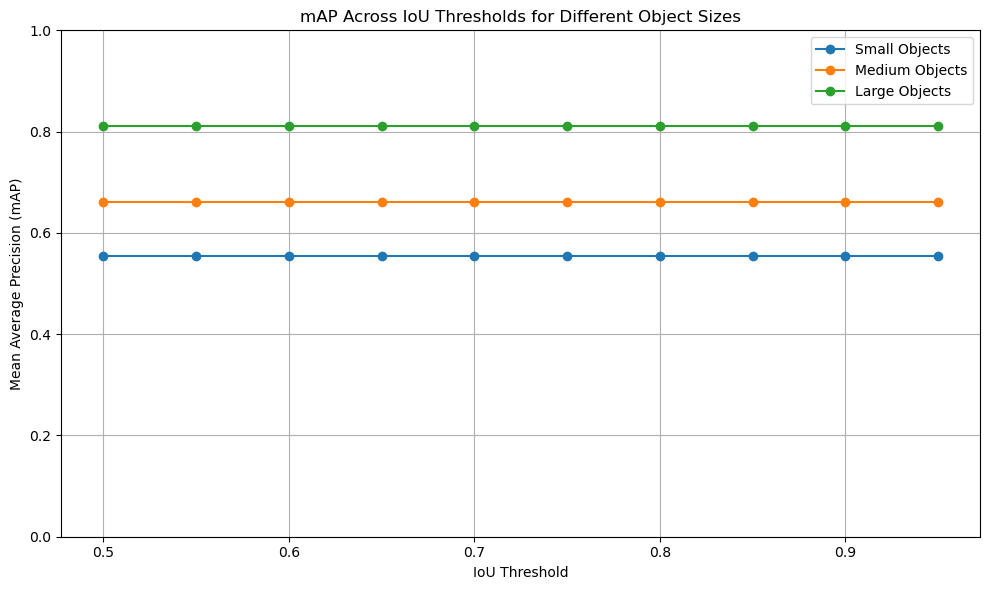

In [ ]:
# Plot mAP Across IoU Thresholds for Each Size Category

import matplotlib.pyplot as plt
import numpy as np

category_ap_iou = {
    'Small': [overall_map_small] * len(iou_thresholds),
    'Medium': [overall_map_medium] * len(iou_thresholds),
    'Large': [overall_map_large] * len(iou_thresholds)
}

# Plotting
plt.figure(figsize=(10, 6))
for size in ['Small', 'Medium', 'Large']:
    plt.plot(iou_thresholds, category_ap_iou[size], marker='o', label=f"{size} Objects")

plt.title("mAP Across IoU Thresholds for Different Object Sizes")
plt.xlabel("IoU Threshold")
plt.ylabel("Mean Average Precision (mAP)")
plt.legend()
plt.grid(True)
plt.ylim(0, 1)
plt.tight_layout()
plt.show()
